# 3.3 波动率类指标

> **这一节讲什么？**  
> 前两节告诉我们「趋势是向上还是向下」「涨跌的力气够不够」。
> 这一节关注另一个维度：**价格波动有多剧烈？**
> 波动率指标帮助我们回答：「现在市场平不平静？止损应该设多远？」

## 学习目标
- 理解布林带（Bollinger Bands）的构造与信号
- 掌握 ATR（真实波动幅度均值）用于止损设置
- 学会用 VIX 和隐含波动率理解市场情绪

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

data = yf.download('AAPL', start='2022-01-01', end='2024-01-01', progress=False)
close = data['Close'].squeeze()
high = data['High'].squeeze()
low = data['Low'].squeeze()

In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 布林带 (Bollinger Bands)

### 为什么需要它？

我们知道均线代表「正常价格水平」。但价格总是在均线上下波动，有时偏离多一点，有时偏离少一点。

布林带的思路是：**给均线加上一个「正常波动范围」的边界。**

用的是统计学里的「标准差」（$\sigma$）——标准差越大，说明价格波动越剧烈，边界越宽；标准差越小，说明价格越稳定，边界越窄。

**类比：** 把布林带想象成一条路的护栏——
- 价格碰到上护栏（上轨）：偏贵了，超出正常范围，可能会回落
- 价格碰到下护栏（下轨）：偏便宜了，可能会回弹
- 护栏越来越窄（带宽收缩）：市场进入低波动期，「平静」之后往往是「突破」

### 公式

$$Middle = SMA_{20} \quad \text{（中轨 = 20日均价）}$$
$$Upper = SMA_{20} + 2\sigma_{20} \quad \text{（上轨 = 均价 + 2倍标准差）}$$
$$Lower = SMA_{20} - 2\sigma_{20} \quad \text{（下轨 = 均价 - 2倍标准差）}$$

正态分布下，价格有约 95% 的概率落在上下轨之间（因为 $\pm 2\sigma$ 覆盖 95% 的分布）。所以「突破上下轨」是相对罕见的事件。

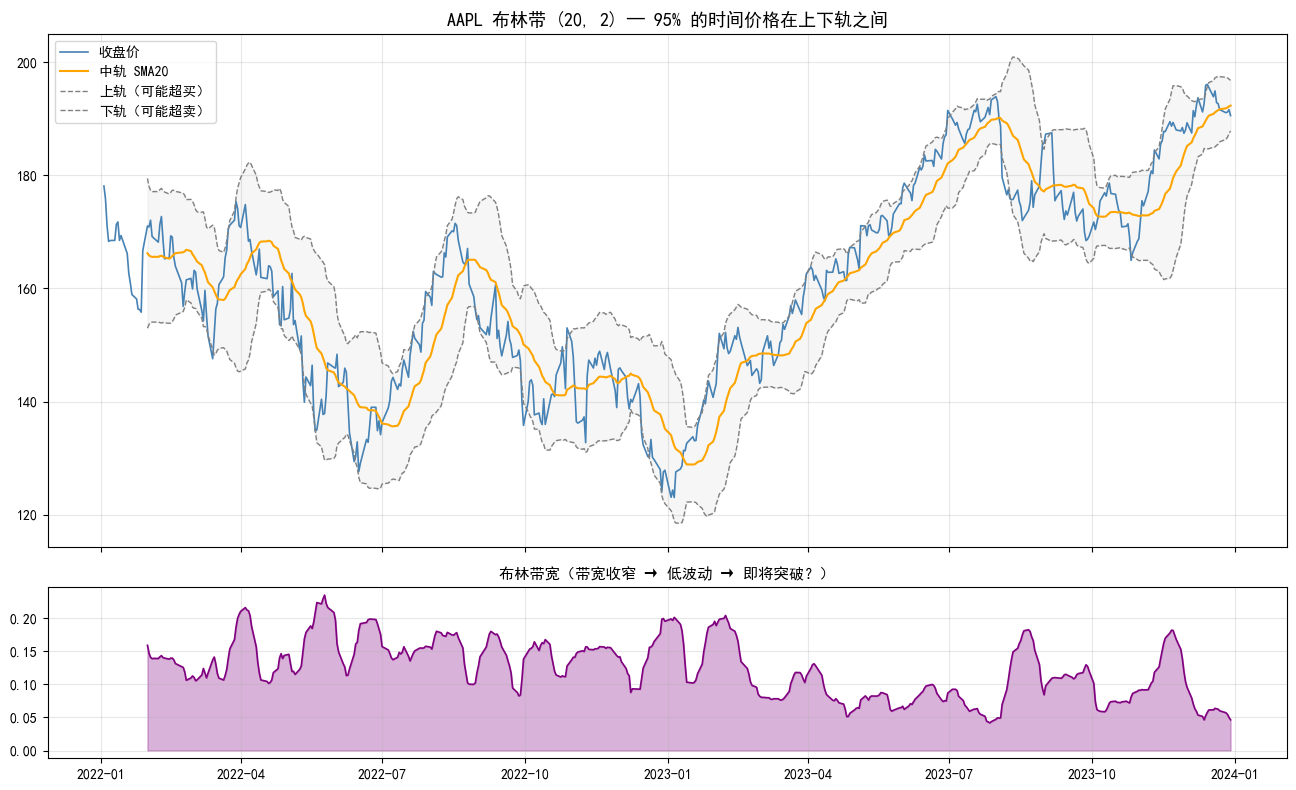

In [3]:
window = 20
n_std = 2

mid = close.rolling(window).mean()
std = close.rolling(window).std()
upper = mid + n_std * std
lower = mid - n_std * std
bandwidth = (upper - lower) / mid  # 带宽（相对值）= 波动程度的量化

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(close.index, close.values, label='收盘价', linewidth=1.2, color='steelblue')
ax1.plot(mid.index, mid.values, label='中轨 SMA20', linewidth=1.5, color='orange')
ax1.plot(upper.index, upper.values, label='上轨（可能超买）', linewidth=1, color='gray', linestyle='--')
ax1.plot(lower.index, lower.values, label='下轨（可能超卖）', linewidth=1, color='gray', linestyle='--')
ax1.fill_between(close.index, upper.values, lower.values, alpha=0.07, color='gray')
ax1.set_title('AAPL 布林带 (20, 2) — 95% 的时间价格在上下轨之间', fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(bandwidth.index, bandwidth.values, color='purple', linewidth=1.2)
ax2.fill_between(bandwidth.index, bandwidth.values, alpha=0.3, color='purple')
ax2.set_title('布林带宽（带宽收窄 → 低波动 → 即将突破？）', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. ATR — 真实波动幅度均值 (Average True Range)

### 为什么需要 ATR？

想象你是一个骑手，骑马走在山路上。
- 平坦的路 → 步伐很稳，每步走 1 米
- 崎岖的山路 → 步伐不稳，每步可能走 3~5 米

**ATR 就是量化「路有多崎岖」——价格每天平均波动多少钱。**

这有什么用？**止损设置！** 

如果苹果每天的正常波动是 2 美元，你把止损设在入场价下 0.5 美元，那一天之内就可能被正常波动触发止损——这不是你真的判断错了，而是止损设得太近。

**经验法则：止损放在 1.5 × ATR 处**——超出日常正常波动范围，只有真正走坏了才会触发。

### 为什么不直接用「最高 - 最低」？

有时候股价会跳空——今天最低价比昨天收盘价还高（跳空高开），最高 - 最低就漏掉了这个「跳空」的距离。ATR 用「真实波幅（True Range）」来修正这个问题：

$$TR = \max\underbrace{(H-L)}_{\text{今日振幅}},\ \underbrace{|H-C_{prev}|}_{\text{上影到昨收距离}},\ \underbrace{|L-C_{prev}|}_{\text{下影到昨收距离}}$$
$$ATR = EMA_{14}(TR) \quad \text{（14日平均真实波幅）}$$

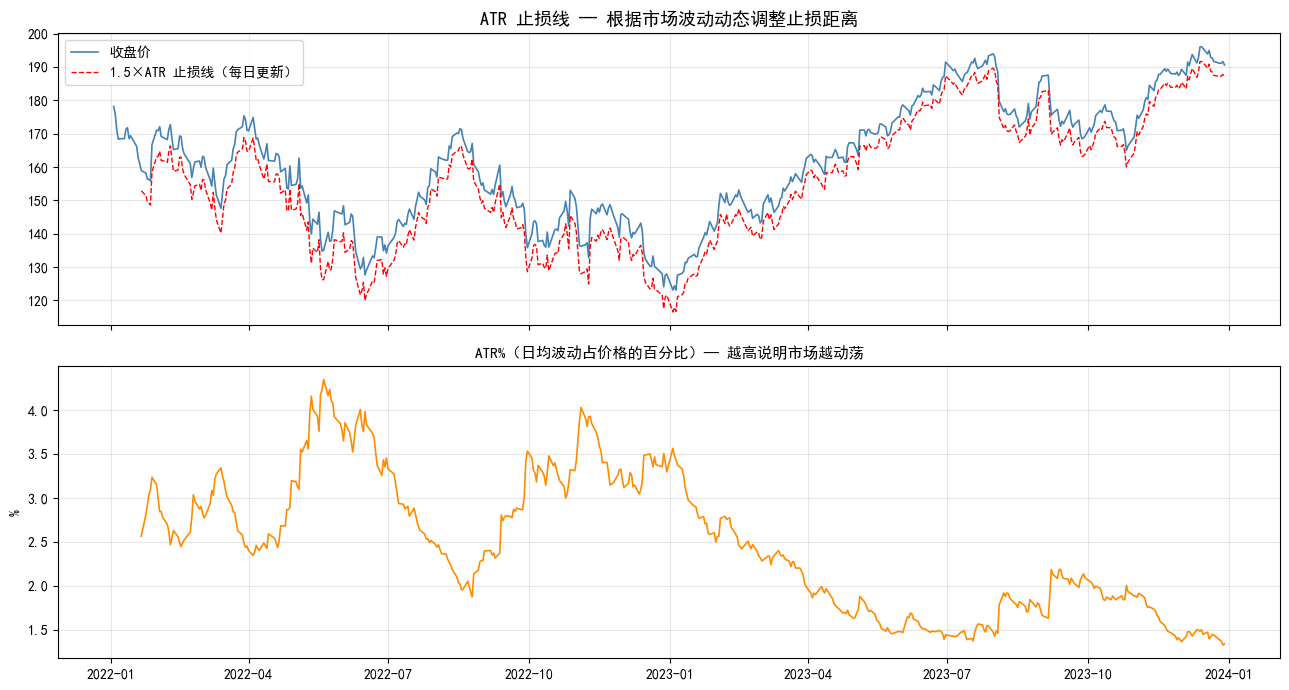

当前 ATR: 2.55 USD（每天平均波动这么多）
建议止损距离（1.5×ATR）: 3.82 USD


In [4]:
def compute_atr(high, low, close, period=14):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,                    # 今日最高 - 最低
        (high - prev_close).abs(),     # 今日最高 - 昨日收盘（处理跳空高开）
        (low - prev_close).abs()       # 今日最低 - 昨日收盘（处理跳空低开）
    ], axis=1).max(axis=1)             # 取三者最大值 = 真实波幅
    atr = tr.ewm(com=period - 1, min_periods=period).mean()
    return atr

atr = compute_atr(high, low, close)
atr_pct = atr / close  # ATR 相对于价格的百分比（方便跨股票比较）

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(close.index, close.values, linewidth=1.2, color='steelblue', label='收盘价')
stop_loss = close - 1.5 * atr  # 止损线 = 收盘价 - 1.5倍ATR
ax1.plot(stop_loss.index, stop_loss.values, linewidth=1, color='red',
          linestyle='--', label='1.5×ATR 止损线（每日更新）')
ax1.set_title('ATR 止损线 — 根据市场波动动态调整止损距离', fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(atr_pct.index, atr_pct.values * 100, color='darkorange', linewidth=1.2)
ax2.set_title('ATR%（日均波动占价格的百分比）— 越高说明市场越动荡', fontsize=11)
ax2.set_ylabel('%')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'当前 ATR: {atr.iloc[-1]:.2f} USD（每天平均波动这么多）')
print(f'建议止损距离（1.5×ATR）: {1.5 * atr.iloc[-1]:.2f} USD')

## 3. VIX — 市场恐慌指数

### 为什么需要 VIX？

ATR 和布林带衡量的是**某只股票**的波动，而 VIX 衡量的是**整个市场的情绪**。

**VIX 是什么？** 它是芝加哥期权交易所（CBOE）基于标普 500 指数期权计算出的「隐含波动率」。简单说，就是**市场参与者愿意花多少钱来买保险**——

- 大家很害怕 → 愿意花高价买保险（期权）→ VIX 飙高
- 大家很淡定 → 不愿意花高价买保险 → VIX 低

**关键规律：**
- **VIX 与市场通常呈负相关**：市场大跌时 VIX 暴涨，市场平稳时 VIX 低迷
- VIX < 15 → 市场极度平静（可能自满，往往是市场顶部前夕的特征）
- VIX > 30 → 市场极度恐慌（历史上往往是逆向做多的好时机）
- VIX = 20 是心理分界线：超过 20 就要开始警惕

**「贪婪时恐惧，恐惧时贪婪」——** VIX 就是量化「恐惧」的温度计。

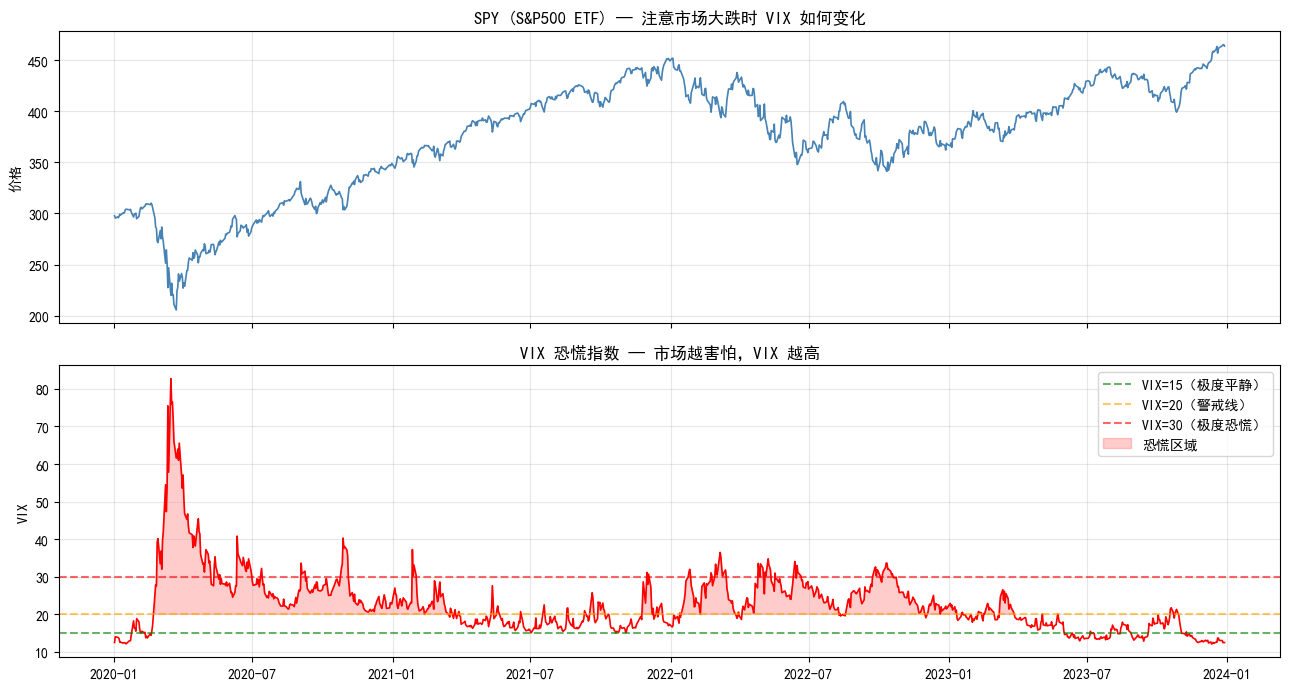

💡 观察：2020年3月（新冠）VIX 曾突破80，历史最高；2022年也有多次超过30


In [5]:
vix = yf.download('^VIX', start='2020-01-01', end='2024-01-01', progress=False)['Close'].squeeze()
spy = yf.download('SPY', start='2020-01-01', end='2024-01-01', progress=False)['Close'].squeeze()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(spy.index, spy.values, color='steelblue', linewidth=1.2)
ax1.set_title('SPY (S&P500 ETF) — 注意市场大跌时 VIX 如何变化', fontsize=12)
ax1.set_ylabel('价格')
ax1.grid(alpha=0.3)

ax2.plot(vix.index, vix.values, color='red', linewidth=1.2)
ax2.axhline(15, color='green', linestyle='--', alpha=0.6, label='VIX=15（极度平静）')
ax2.axhline(20, color='orange', linestyle='--', alpha=0.6, label='VIX=20（警戒线）')
ax2.axhline(30, color='red', linestyle='--', alpha=0.6, label='VIX=30（极度恐慌）')
ax2.fill_between(vix.index, vix.values, 20, where=(vix.values > 20),
                  alpha=0.2, color='red', label='恐慌区域')
ax2.set_title('VIX 恐慌指数 — 市场越害怕，VIX 越高', fontsize=12)
ax2.set_ylabel('VIX')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('💡 观察：2020年3月（新冠）VIX 曾突破80，历史最高；2022年也有多次超过30')

## 🎯 练习

1. 布林带带宽收窄到历史低点后，价格通常会如何运动？找 2 个历史例子验证（提示：观察带宽的局部最小值之后价格的走势）。
2. **ATR 仓位管理**：假设你的账户是 100,000 元，每笔最大亏损是总资金的 1%（即 1000 元）。如果 ATR = 2 美元，止损设 1.5×ATR，你能买多少股？（答：1000 / (1.5×2) = 333 股）
3. 实现 ATR 追踪止损（Trailing Stop）：止损线随价格上涨而上移，但不随价格下跌而下移。

---
**下一模块** → `../04_backtesting/01_simple_backtest.ipynb`